# Low Fidelity Neural Network
Neural Network which uses LF dataset and exploits the Low fidelity component of the MF model. The NN is tested also on the HF test set  

In [1]:
#########################     LIBRARIES     ##########################
import keras.backend as K
import numpy as np


import keras
import tensorflow as tf
from source.Diffusion_helper import *
from utils.functions_to_ray import *


from utils.network_utils import *

from pathlib import Path


True

In [2]:
# reproducibility
def set_seed():
        
    seed = 42
    np.random.seed(seed)
    keras.utils.set_random_seed(seed)
    tf.random.set_seed(seed)

# Data Preparation

In [3]:
file_path_LF = "../DATA_reaction_diffusion_test_case/reaction_diffusion_LF_46_d1.mat"
(reaction_LF_test, U_LF_test) = import_data(file_path_LF)

U_LF_test = U_LF_test[:, -1, 12,12]


reaction_LF_test = Helpers_NN.normalization(reaction_LF_test)
U_LF_test=Helpers_NN.normalization(U_LF_test)

reaction_LF_test_original=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]
U_LF_test_original=U_LF_test




In [5]:
noise_stddev2=[0.02, 0.01,0.02,0.01, 0.02,0.01  ]
noise_stddev1=[0.01,0.005,0.01,0.005,0.005, 0.01 ]

(U_LF_test,reaction_LF_test)=Helpers_NN.add_noise(noise_stddev1,noise_stddev2,reaction_LF_test,U_LF_test.reshape(-1,1))
reaction_LF_test=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]

In [6]:
permutation = np.random.permutation(len(reaction_LF_test))

NepoLF = 7000  # number of epochs 
Nlf = 200

reaction_LF = reaction_LF_test[permutation][0:Nlf,:]
U_LF = U_LF_test[permutation][0:Nlf]

# Low Fidelity Neural Network
## Low fidelity data

In [7]:
name = "LF"  # I leave the same NN,  even if we use HF data instead of LF
K.clear_session()
best_params = {
    'kernel_init': 'glorot_uniform',
    'l2weight': 0.03711750915883216,
    'lr': 0.024244197598433916,
    'opt': 'Adamax'
}



LF Model:
The function training took 158.740103 seconds.


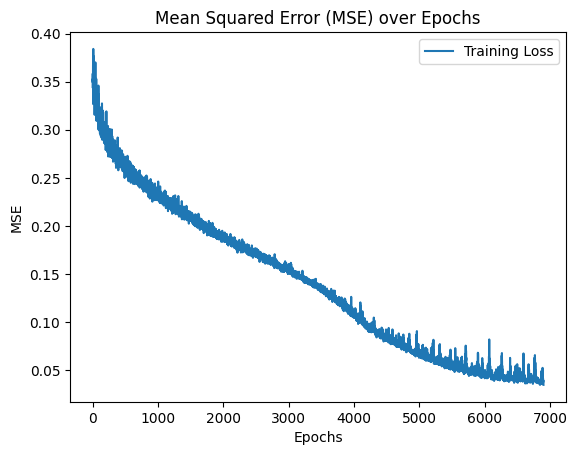

Test MSE: 0.006638256647743399
R^2: 0.9448596055556713


In [8]:
####################    NN training and PREDICTION    #######################

print("\nLF Model:")


definition_LF={
        "network_type": "LF",
        "network_parameters": best_params,
        "dataset_train": reaction_LF,
        "output_train": U_LF,
        "epochs_number": NepoLF,
        "batch_size": Nlf,
        "train": True,
        "do_HPO": False,
        "verbose": False
    }
model= NetworkFactory.build_network(NetworkConfig(**definition_LF),Diffusion_model_helpers.getModel)
ULF = model.prediction(reaction_LF_test_original)

(mse_LF,R_LF) = model.performance(reaction_LF_test_original,U_LF_test_original)


## High Fidelity data

In [9]:

file_path_HF = "..//DATA_reaction_diffusion_test_case/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test) = Diffusion_model_helpers.import_data(file_path_HF)

# correspondent U value in the HF scenario
U_HF_test = U_HF_test[
    :, -1, 44,44
]

U_HF_test = Helpers_NN.normalization(U_HF_test)
reaction_HF_test = Helpers_NN.normalization(reaction_HF_test)
reaction_HF_test_original=np.c_[reaction_HF_test, np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0]-5*np.pi/6))]
U_HF_test_original=U_HF_test

UHF = model.prediction(reaction_HF_test_original)
(mse_HF,R_HF) = model.performance(reaction_HF_test_original,U_HF_test_original)


Test MSE: 0.18235447984519626
R^2: -0.610922560973578


# Plot

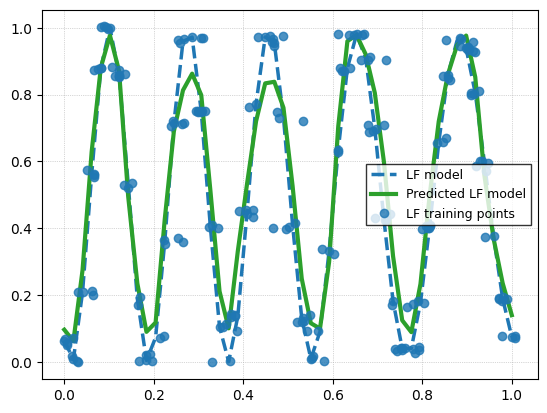

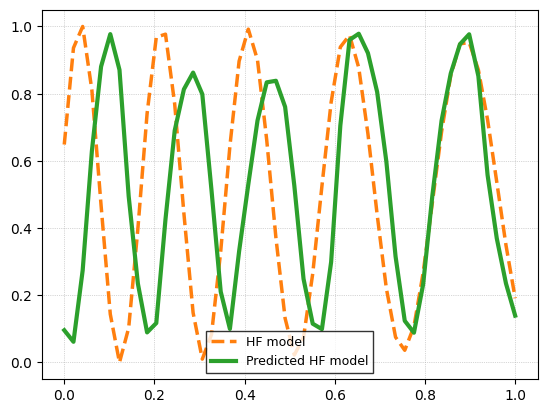

In [12]:
Diffusion_model_helpers.plot_results(reaction_LF_test_original, U_LF_test_original, ULF, "LF",reaction_LF, U_LF, "#1F77B4", "#2CA02C", "LF model", "Predicted LF model")

Diffusion_model_helpers.plot_results(reaction_HF_test_original, U_HF_test_original,model.prediction(reaction_HF_test_original), "HF",None,None, "#FF7F0E", "#2CA02C", "HF model", "Predicted HF model")
